In [14]:
# Importation de la bibliothèque pandas pour la manipulation de données sous forme de DataFrame
import pandas as pd  

# Importation de numpy pour les calculs numériques et les tableaux multidimensionnels
import numpy as np  

# Importation de matplotlib.pyplot pour la visualisation graphique
import matplotlib.pyplot as plt  

# Importation de LinearRegression de scikit-learn pour créer un modèle de régression linéaire
from sklearn.linear_model import LinearRegression  

# Importation de PolynomialFeatures pour transformer les données afin de faire de la régression polynomiale
from sklearn.preprocessing import PolynomialFeatures  

# Importation de train_test_split pour diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split  

# Importation de mean_squared_error et r2_score pour évaluer la performance du modèle
from sklearn.metrics import mean_squared_error, r2_score  

In [2]:
data = pd.read_csv("Employers_data.csv")
data.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [3]:
X = data[['Age','Experience_Years']]
y = data['Salary']

In [4]:
# Afficher les informations générales sur le dataset
print(data.info())

# Afficher des statistiques descriptives 
print(data.describe())

# Vérifier s'il existe des valeurs manquantes dans chaque colonne
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       10000 non-null  int64 
 1   Name              10000 non-null  object
 2   Age               10000 non-null  int64 
 3   Gender            10000 non-null  object
 4   Department        10000 non-null  object
 5   Job_Title         10000 non-null  object
 6   Experience_Years  10000 non-null  int64 
 7   Education_Level   10000 non-null  object
 8   Location          10000 non-null  object
 9   Salary            10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
None
       Employee_ID           Age  Experience_Years         Salary
count  10000.00000  10000.000000      10000.000000   10000.000000
mean    5000.50000     35.455900         12.370900  115381.500000
std     2886.89568     10.000213          9.148951   46066.139047
min        1.00000 

In [33]:
# Variable explicative 
X = data[['Experience_Years']]

# Variable cible
y = data['Salary']

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


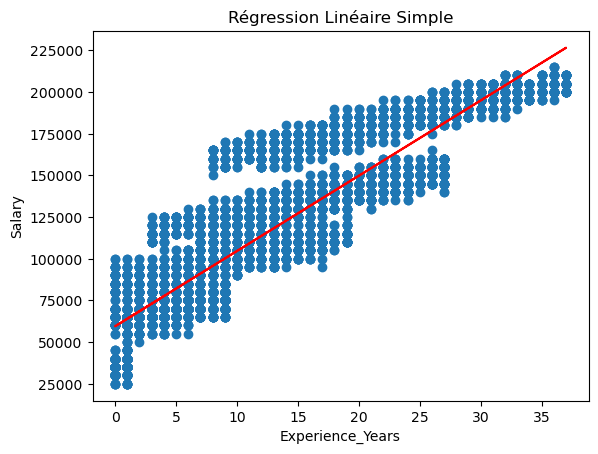

In [36]:
# Tracer les points
plt.scatter(data['Experience_Years'], data['Salary'])

# Ajouter la droite de régression
plt.plot(data['Experience_Years'], model_simple.predict(data[['Experience_Years']]), color='red')

# Nom des axes
plt.xlabel("Experience_Years")
plt.ylabel("Salary")

# Titre
plt.title("Régression Linéaire Simple")

# Affichage
plt.show()

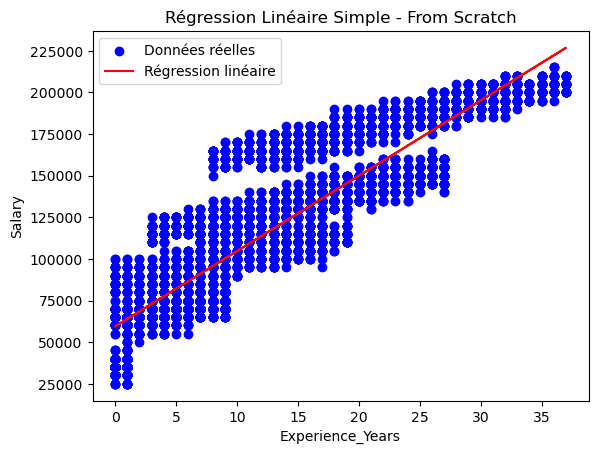

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# je prends ma variable explicative X, ici c'est juste l'expérience des employés
# Et y, c'est le salaire correspondant
X = data[['Experience_Years']].values
y = data['Salary'].values

# Comme on veut un intercept dans notre droite (sinon ça passerait par 0)
# je crée une colonne de 1 et je la colle devant X
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Là, je calcule directement les coefficients de ma droite avec l'équation normale
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
# Maintenant que j'ai mes coefficients, je peux prédire les salaires pour mes X
y_pred = X_b.dot(theta)
# Scatter pour voir les vraies données
# Plot pour la droite de régression que j'ai calculée
plt.scatter(X, y, color='blue', label='Données réelles')
plt.plot(X, y_pred, color='red', label='Régression linéaire')
plt.xlabel("Experience_Years")  #  X c'est l'expérience
plt.ylabel("Salary")            # Et Y le salaire
plt.title("Régression Linéaire Simple - From Scratch")  # Titre du graphique
plt.legend()  # Affiche la légende 
plt.show() 

===== Régression Linéaire Multiple =====
MSE : 277978319.9059728
R2 : 0.8681105790538133


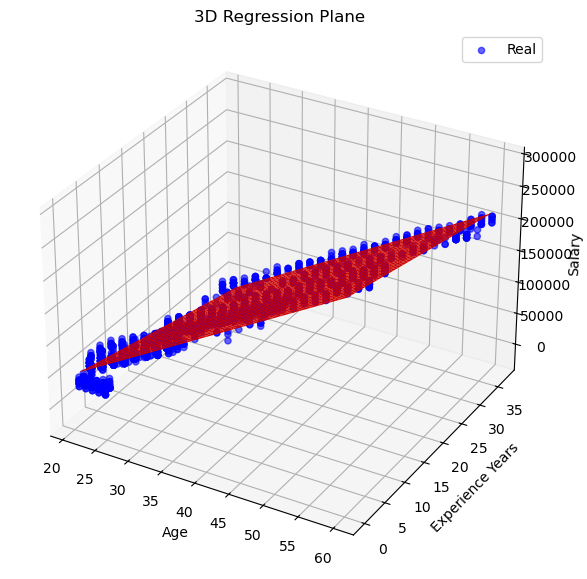

In [29]:
# Sélection des variables explicatives (features) : Age et Experience_Years
X = data[['Age', 'Experience_Years']]

# Sélection de la variable cible (target) : Salary
y = data['Salary']

# Division des données en ensembles d'entraînement (80%) et de test (20%)
# random_state=42 assure la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création du modèle de régression linéaire multiple
model_multiple = LinearRegression()

# Entraînement du modèle sur les données d'entraînement
model_multiple.fit(X_train, y_train)

# Prédiction des salaires sur les données de test
y_pred_m = model_multiple.predict(X_test)

# Calcul des performances du modèle
mse_multiple = mean_squared_error(y_test, y_pred_m)
# r2_score mesure la proportion de variance expliquée par le modèle (plus proche de 1 = meilleur)
r2_multiple = r2_score(y_test, y_pred_m)

# Affichage des résultats
print("===== Régression Linéaire Multiple =====")
print("MSE :", mse_multiple)
print("R2 :", r2_multiple)

# Création d'une figure 3D pour visualiser la régression
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot des points réels
# X_test['Age'] et X_test['Experience_Years'] = coordonnées
# y_test = valeurs réelles de Salary
ax.scatter(X_test['Age'], X_test['Experience_Years'], y_test,
           color='blue', label='Real', alpha=0.6)

# Création d'une grille pour tracer le plan de régression
# np.linspace génère des valeurs uniformément espacées entre min et max
age_range = np.linspace(X['Age'].min(), X['Age'].max(), 30)
exp_range = np.linspace(X['Experience_Years'].min(), X['Experience_Years'].max(), 30)

# Création d'une grille 2D à partir des plages Age et Experience
age_grid, exp_grid = np.meshgrid(age_range, exp_range)

# Préparation des données de la grille pour la prédiction
grid_df = pd.DataFrame({
    'Age': age_grid.ravel(),                # aplatissement en 1D
    'Experience_Years': exp_grid.ravel()
})

# Prédiction des valeurs du salaire sur toute la grille
# reshape pour correspondre à la forme 2D de la grille
z_pred = model_multiple.predict(grid_df).reshape(age_grid.shape)

# Tracé de la surface du plan de régression
ax.plot_surface(age_grid, exp_grid, z_pred,
                color='red')

# Ajout des labels et titre
ax.set_xlabel("Age")
ax.set_ylabel("Experience Years")
ax.set_zlabel("Salary")
ax.set_title("3D Regression Plane")

# Légende
ax.legend()

# Affichage de la figure
plt.show()

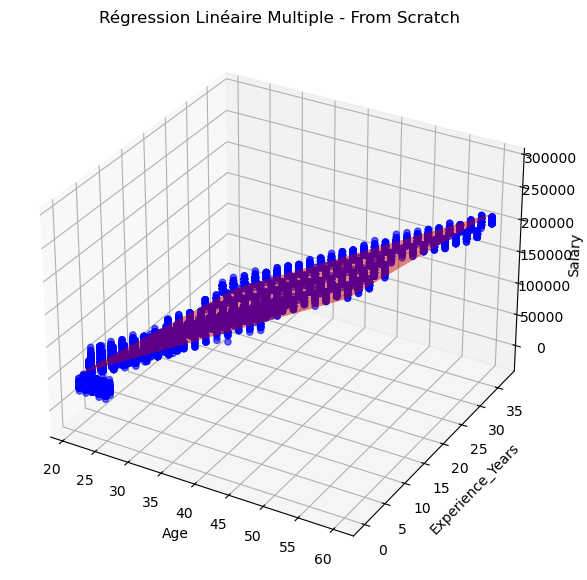

In [30]:
# importer le module pour faire des graphes en 3D
from mpl_toolkits.mplot3d import Axes3D

# récupérer les variables Age et Experience sous forme de tableau numpy
X = data[['Age', 'Experience_Years']].values

# récupérer la variable cible (Salary)
y = data['Salary'].values

# ajouter une colonne de 1 pour prendre en compte le biais (intercept)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# calcul des coefficients theta avec la formule (X^T X)^-1 X^T y
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# une plage de valeurs pour Age (pour tracer le plan)
age_range = np.linspace(X[:,0].min(), X[:,0].max(), 30)

# créer une plage de valeurs pour Experience
exp_range = np.linspace(X[:,1].min(), X[:,1].max(), 30)

# une grille 2D avec toutes les combinaisons Age / Experience
age_grid, exp_grid = np.meshgrid(age_range, exp_range)

# préparer les données de la grille pour faire les prédictions
X_grid = np.c_[np.ones(age_grid.ravel().shape), age_grid.ravel(), exp_grid.ravel()]

# calcule les valeurs prédites (salary) pour chaque point de la grille
z_pred = X_grid.dot(theta).reshape(age_grid.shape)

# créer la figure
fig = plt.figure(figsize=(10,7))

# un graphique 3D
ax = fig.add_subplot(111, projection='3d')

# afficher les points réels (les données du dataset)
ax.scatter(X[:,0], X[:,1], y, color='blue', alpha=0.6, label='Données réelles')

# afficher le plan de régression (surface)
ax.plot_surface(age_grid, exp_grid, z_pred, color='red', alpha=0.5)

# nom de l’axe X
ax.set_xlabel("Age")

# nom de l’axe Y
ax.set_ylabel("Experience_Years")

# nom de l’axe Z
ax.set_zlabel("Salary")

# titre du graphique
ax.set_title("Régression Linéaire Multiple - From Scratch")

# afficher le graphique
plt.show()

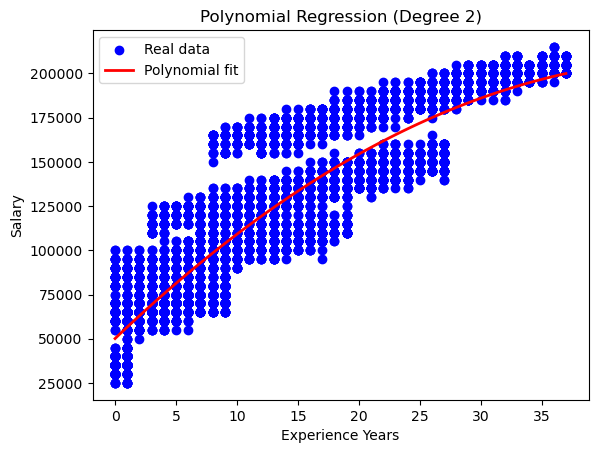

In [27]:
# afficher les points réels (expérience vs salaire)
plt.scatter(X['Experience_Years'], y, color='blue', label='Real data')

# créer une plage de valeurs continues pour Experience (pour lisser la courbe)
X_range = np.linspace(
    X['Experience_Years'].min(),   # valeur min
    X['Experience_Years'].max(),   # valeur max
    100                           # nombre de points
).reshape(-1, 1)

# convertir en DataFrame pour garder le même format que les données initiales
X_range_df = pd.DataFrame(X_range, columns=['Experience_Years'])

# transformer les données en polynomiales 
X_range_poly = poly.transform(X_range_df)

# les prédictions avec le modèle polynomiale
y_range_pred = model_poly.predict(X_range_poly)

# tracer la courbe de régression polynomiale
plt.plot(X_range_df, y_range_pred, color='red', linewidth=2, label='Polynomial fit')

# nom de l’axe X
plt.xlabel("Experience Years")

# nom de l’axe Y
plt.ylabel("Salary")

# titre du graphique
plt.title("Polynomial Regression (Degree 2)")

# afficher la légende (real data / polynomial fit)
plt.legend()

# afficher le graphique
plt.show()

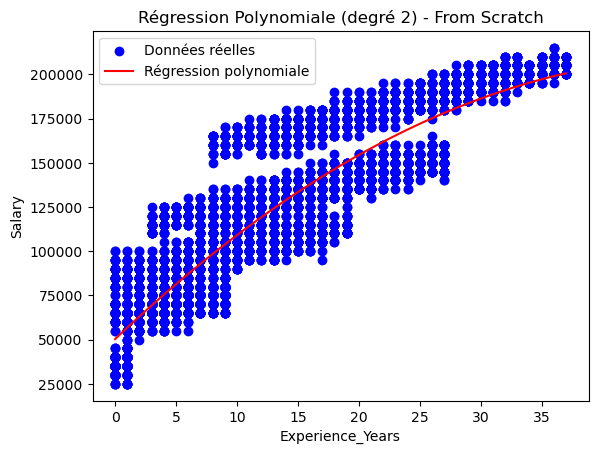

In [23]:
# Sélection de la variable explicative (Experience_Years) et conversion en array numpy
X = data[['Experience_Years']].values

# Sélection de la variable cible (Salary) et conversion en array numpy
y = data['Salary'].values

# Création des features polynomiales pour une régression quadratique (degré 2)
# np.ones(...) ajoute la colonne de 1 pour le biais (intercept)
# X = x et X**2 = x^2
X_poly = np.c_[np.ones((X.shape[0], 1)), X, X**2]

# Calcul des coefficients (theta) via la formule analytique des moindres carrés
# θ = (X^T X)^(-1) X^T y
theta = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

# Prédiction des valeurs de y pour les données originales
y_pred = X_poly.dot(theta)

# Tracé des points réels
plt.scatter(X, y, color='blue', label='Données réelles')

# pour la création d'une plage lisse pour tracer la courbe de régression
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)

# pour la création des features polynomiales pour la plage lisse
X_range_poly = np.c_[np.ones((X_range.shape[0],1)), X_range, X_range**2]

# Prédiction sur la plage lisse
y_range_pred = X_range_poly.dot(theta)

# pour tracé de la courbe de régression polynomiale
plt.plot(X_range, y_range_pred, color='red', label='Régression polynomiale')

# Labels et titre du graphique
plt.xlabel("Experience_Years")
plt.ylabel("Salary")
plt.title("Régression Polynomiale (degré 2) - From Scratch")

# Légende
plt.legend()

# Affichage du graphique
plt.show()